In [1]:
from escripts import eplots
from escripts import eMCMC
from escripts import edata
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib.patches as mpatches
import math
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import emcee
import zeus21
import matplotlib

In [2]:
backend_file = '/Users/eb35267/Desktop/code/chains/min_sig_0.3/add_dlogMcdz/samples.h5'

In [2]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Donnan24_high_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Kokorev+25.txt',
             '/Users/eb35267/Desktop/code/home/data/Weibel+25_upper_limits.txt']
data_labels = ['Bouwens+21', 'Donnan+24', r'Donnan+24 ultra high-$z$', 'Kokorev+25', 'Weibel+25']
include = [True, True, False, False, False]
sorted_data = edata.get_sorted(file_names, data_labels, include_in_likelihood=include)

In [257]:
params = eMCMC.build_param_data({'dalphadz':{'fit':True}, 'dbetadz':{'fit':True}, 'dlogMcdz':{'fit':True}, 'dlogedz':{'fit':True}, 'dsigdz': {'fit': True}, 'dsigdlogM':{'fit':True}, 'min_sig':{'fit':True}, 'C0':{'fit':True}, 'C1':{'fit':True}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [258]:
samples, best_fit, bounds, param_labels = my_UVLF.get_fit(backend_file = backend_file)

IndexError: index 7 is out of bounds for axis 0 with size 7

# Corner plot

In [ ]:
backend_file = '/Users/eb35267/Desktop/code/chains/min_sig_0.3/add_dsigdlogM/samples.h5'

In [4]:
params = eMCMC.build_param_data({'dsigdz': {'fit': True}, 'dsigdlogM':{'fit':True}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [ ]:
samples, best_fit, bounds, param_labels = my_UVLF.get_fit(backend_file = backend_file)

KeyboardInterrupt: 

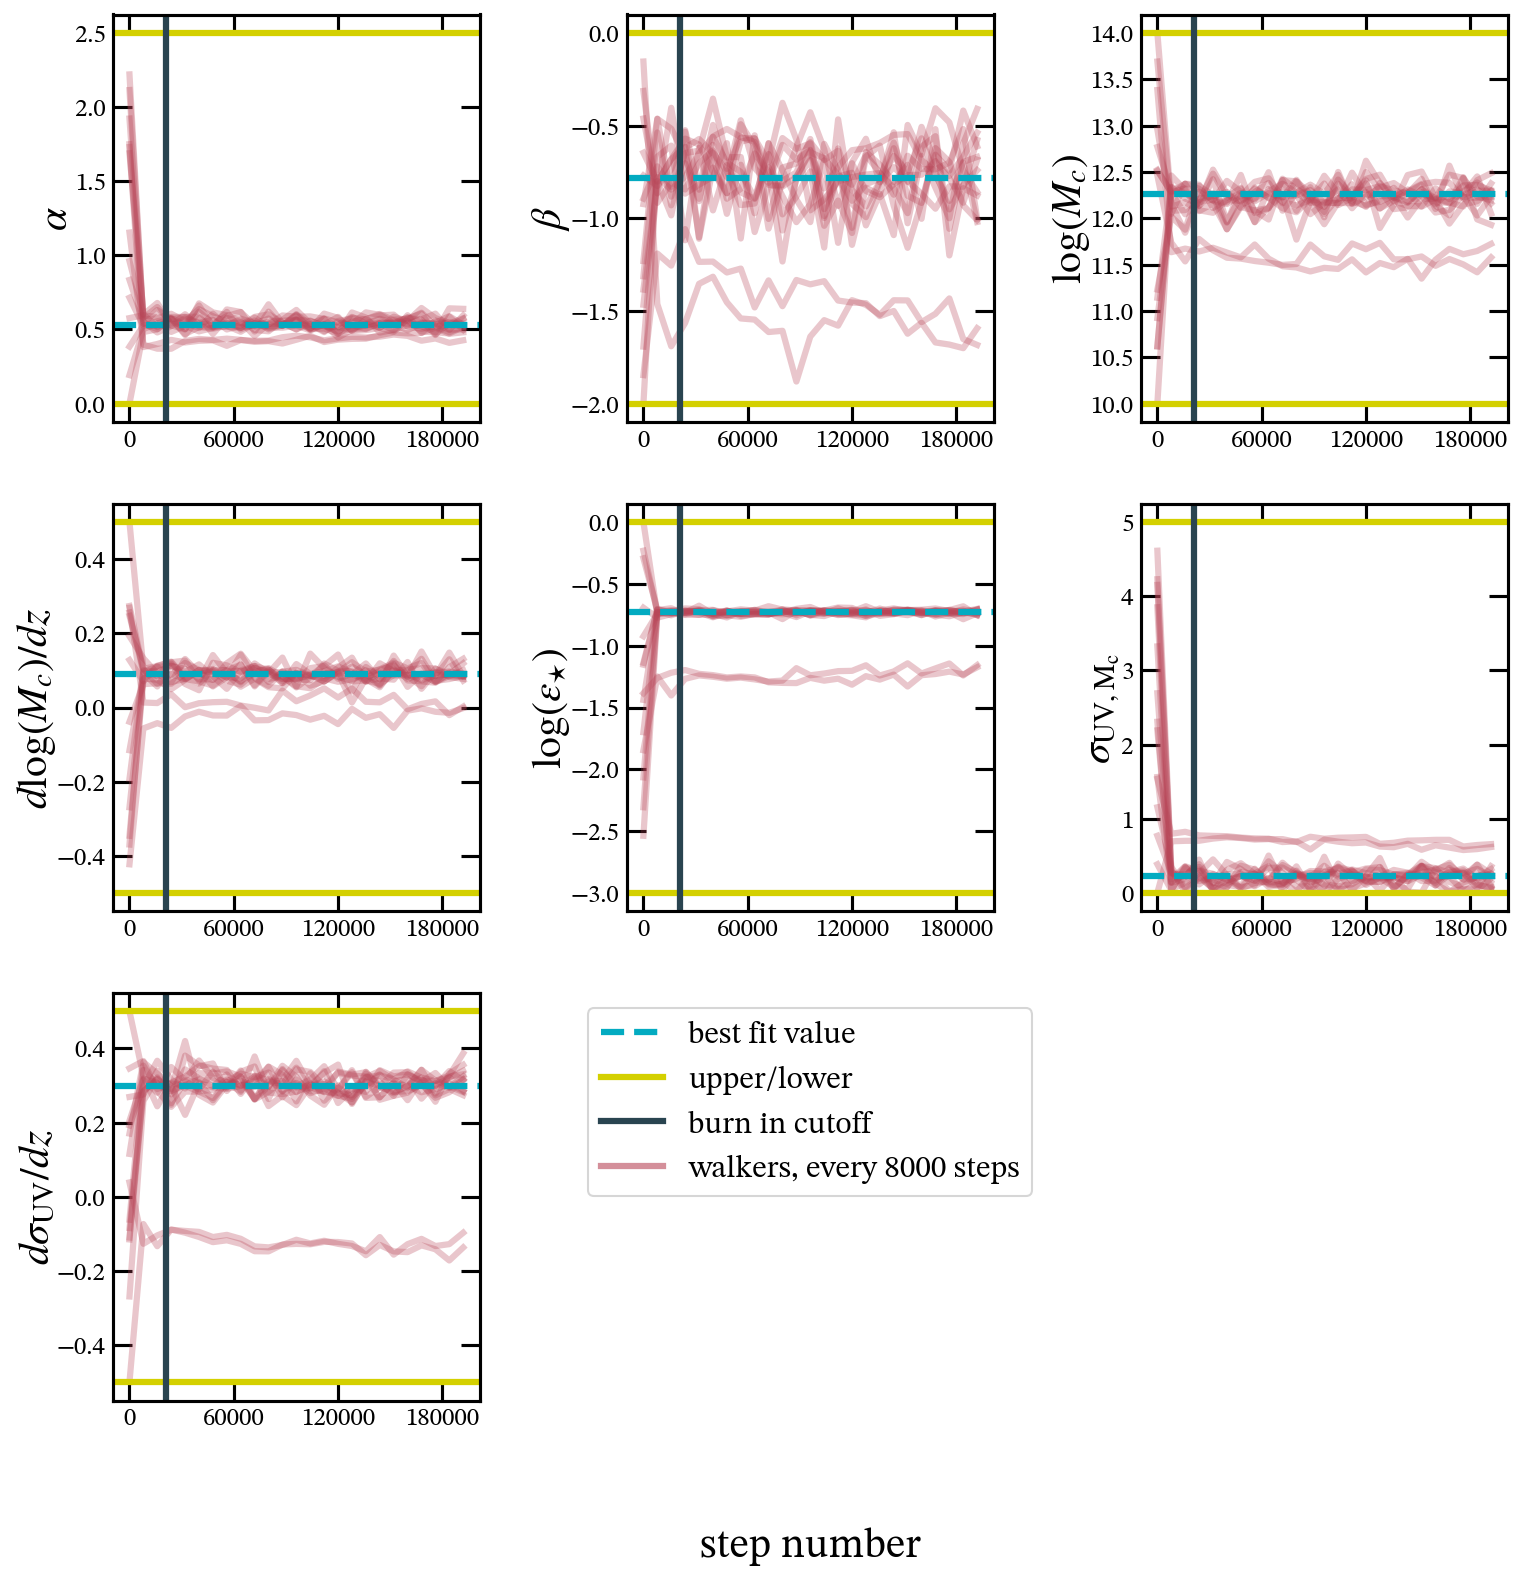

In [ ]:
walkers = eplots.walkers(backend_file = backend_file, my_UVLF = my_UVLF, burn_in = 21000, param_values = best_fit)

In [225]:
reader = emcee.backends.HDFBackend(backend_file)
sample_not_flat = reader.get_chain(discard = 21000, flat=False)

In [243]:
sample_not_flat[:,11][:,-1]

array([-0.10244766, -0.09746989, -0.082244  , ..., -0.15535727,
       -0.15535727, -0.14463935])

In [247]:
cut_sample = np.delete(sample_not_flat, [3, 11], axis = 1) # Delete the two walkers that got stuck

In [250]:
cut_sample_flat = cut_sample.reshape(-1, 7) # Flatten

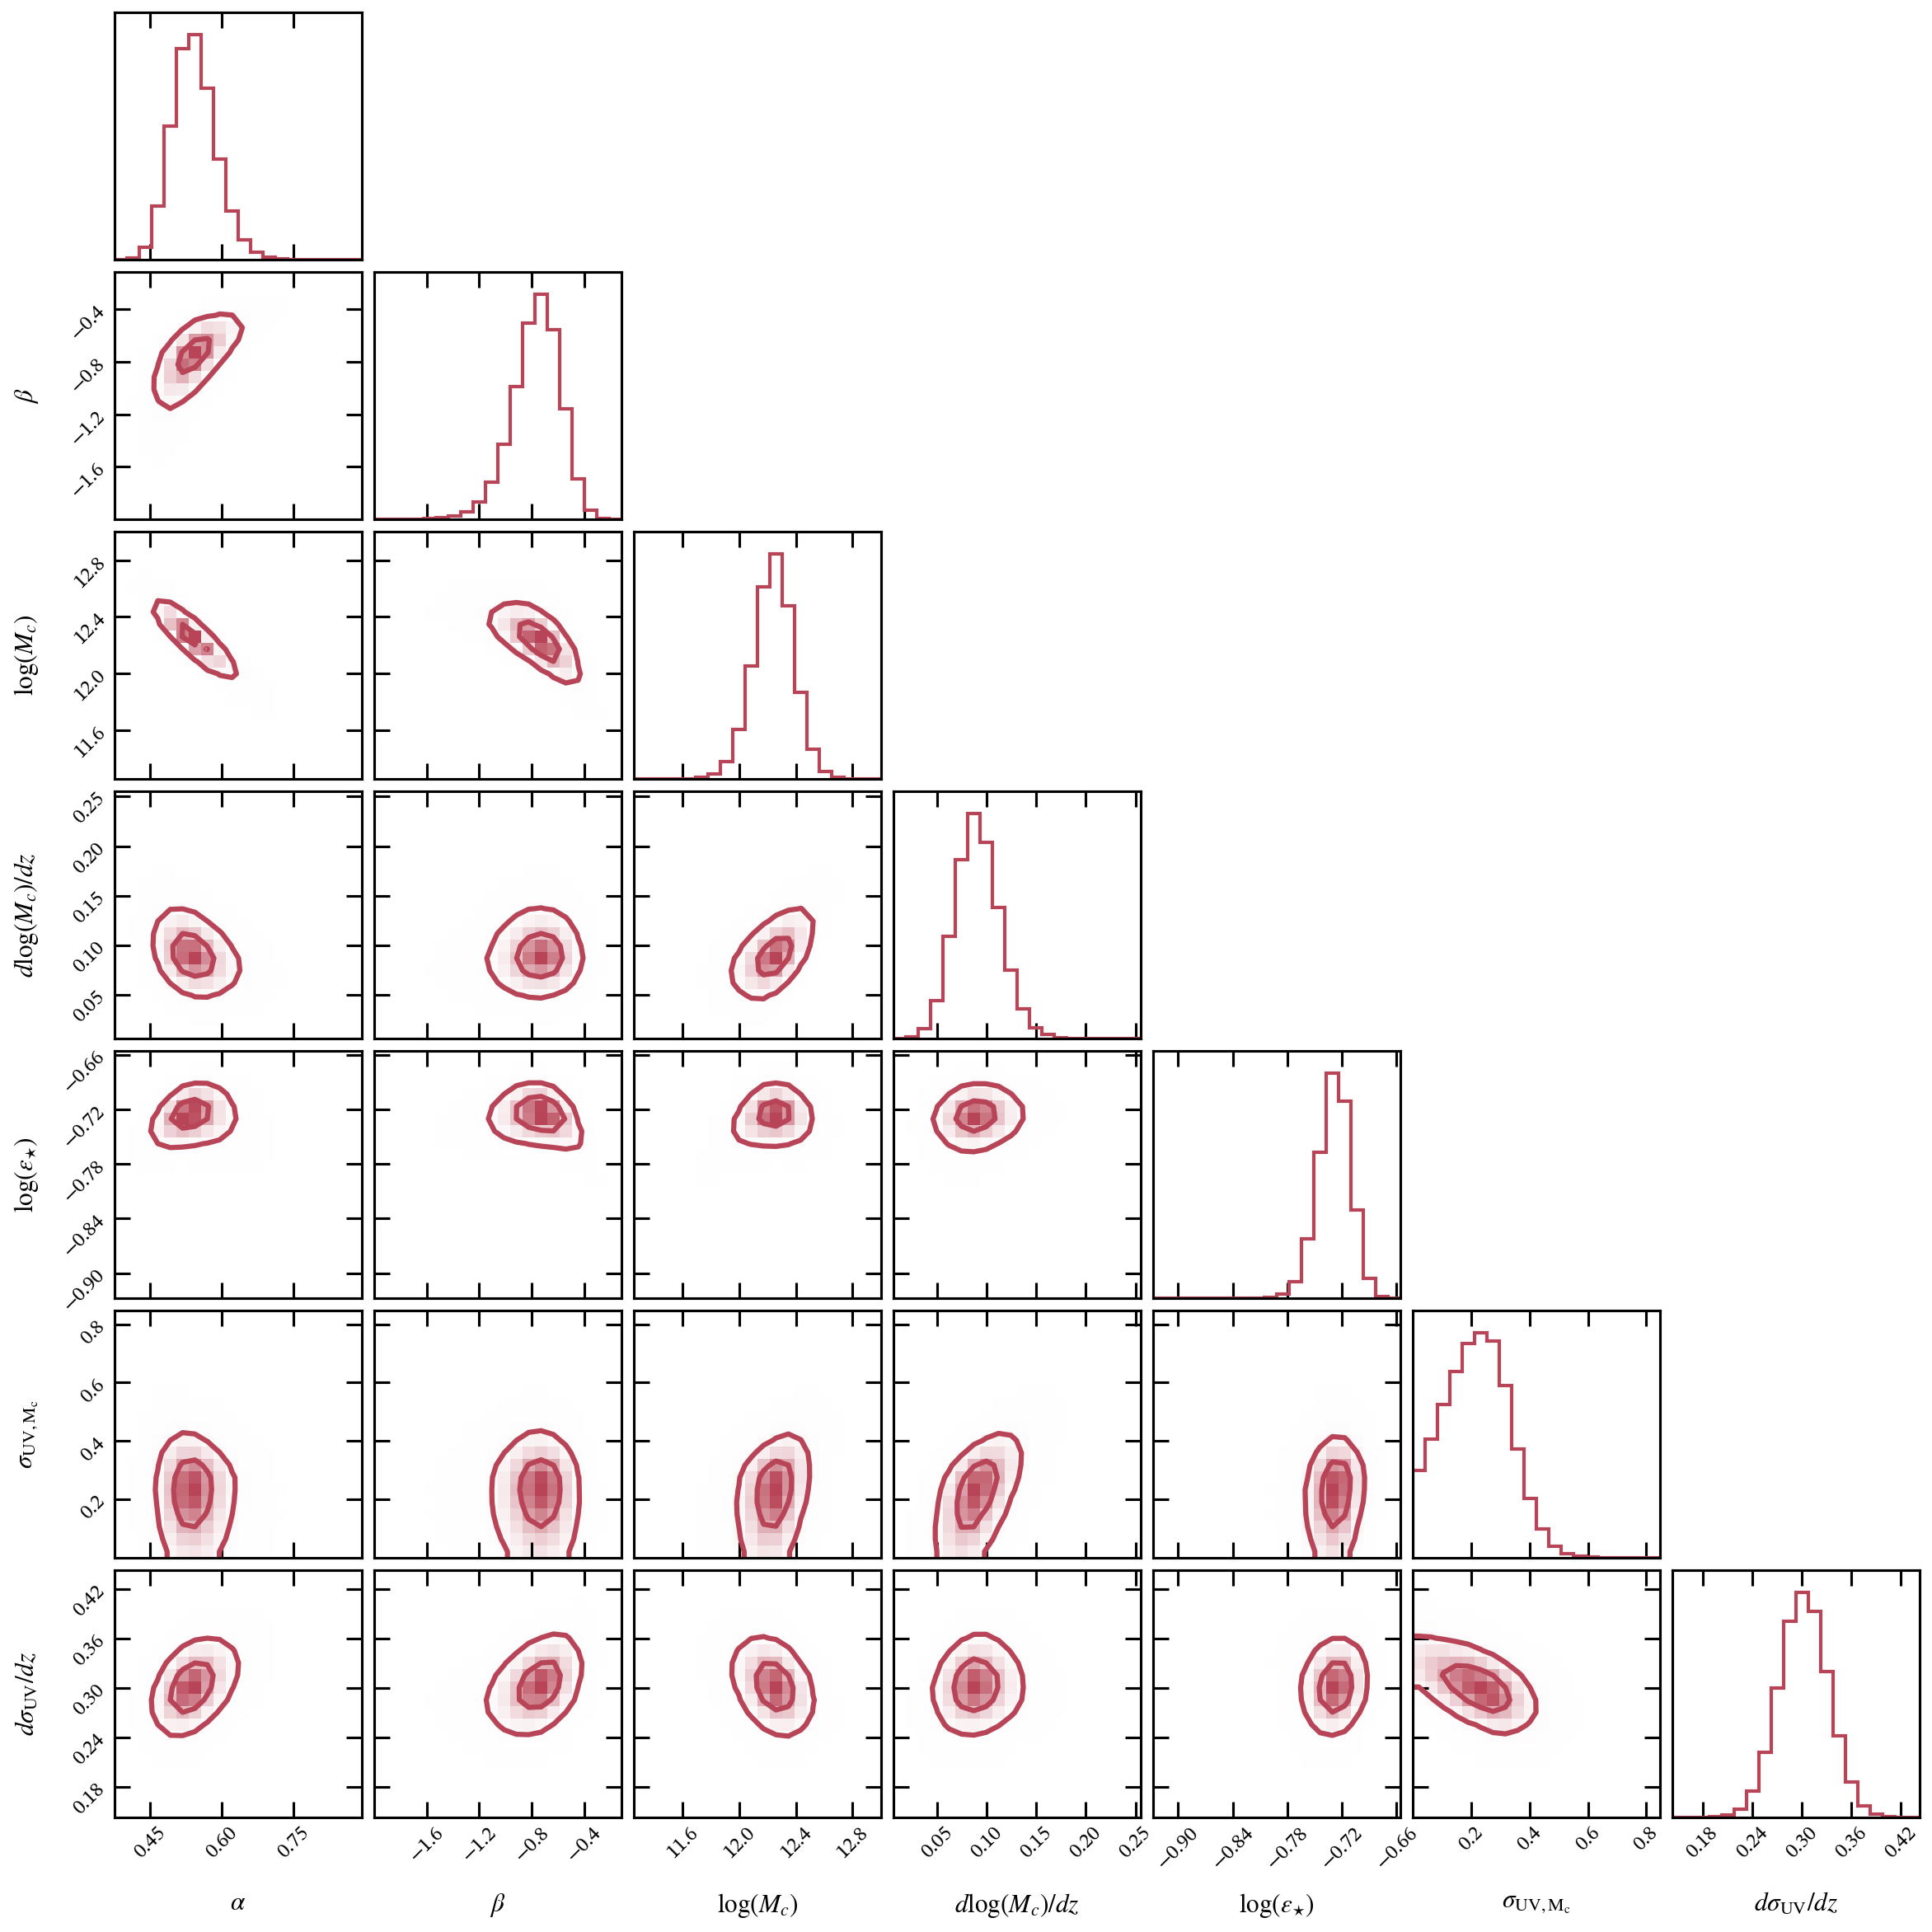

In [251]:
other_corner = eplots.make_corner(my_UVLF = my_UVLF, samples = cut_sample_flat)

In [218]:
corner = eplots.make_corner(my_UVLF = my_UVLF, samples = cut_sample_flat, include_params = ['dsigdz', 'dsigdlogM'])

# for ax, zorder in zip([corner.axes[0], corner.axes[2]], [2, 1]):
#     ax.set_xlim(0.01, None)

# corner.axes[3].set_xlim(-1.3, 0.95)
# corner.axes[2].set_ylim(-1.3, 0.95)

corner.axes[0].axvline(best_fit[-2], color = eplots.navy, zorder = 1, lw = 1, ls = 'dotted')
corner.axes[2].fill_between([-1, 1], -0.4, -0.2, color = eplots.yellow, alpha = 0.3, zorder = 1)
corner.axes[3].fill_between([-0.4, -0.2], 0, 1e6, color = eplots.yellow, alpha = 0.3, zorder = 0)
corner.axes[3].axvline(best_fit[-1], color = eplots.navy, lw = 1, ls = 'dotted')

corner.axes[2].scatter(best_fit[-2], best_fit[-1], color = eplots.navy, s = 100, marker = '+', zorder = 2)

line = Line2D([0], [0], color=eplots.navy, lw = 1, ls = 'dotted')
scat = Line2D([0], [0], color=eplots.navy, marker='+', markersize=10, linestyle='None', markeredgewidth=3)
fill = mpatches.Patch(color=eplots.yellow, alpha=0.3)

corner.axes[1].legend([(line, scat), fill], ['best fit', 'Gelli+24,\nMuñoz+26'],
                      handler_map={(line, scat): HandlerTuple(ndivide=None)})

# corner.axes[1].scatter(0, -10, color = eplots.navy, s = 100, marker = '+', label = 'best fit')
# corner.axes[1].fill_between([0,0], 0, 0, color = eplots.turquoise, alpha = 0.2, label = 'other work')
# corner.axes[1].plot(0,0, color = eplots.navy, label = 'best fit')
# corner.axes[1].legend()

NameError: name 'cut_sample_flat' is not defined

In [192]:
corner.savefig('/Users/eb35267/Desktop/figures/paper/corner.png', dpi = 300)

# UVLF

In [ ]:
def evolving_UVLF_fit(my_UVLF, backend_file = None, z_plot = None, z_errs = None, plot_from_chain = True, nsamples = 100, 
                      
                      comparison_fits = [], comparison_labels = [], 
                      ncols = 3, burn_in = None, show_chi2 = True, data_fmt = None, fit_colors = None, MUV_dat = None, ylims = None, max_sigs = None):

    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data

    if z_plot is None:
        z_plot = data_z
        z_errs = [dat[1] for dat in my_UVLF.data]
        dat = my_UVLF.data
    else:
        if z_errs is None:
            z_errs = np.full_like(z_plot, 0.5, dtype = float)
        if type(z_plot) == list:
            z_plot = np.array(z_plot, dtype = float)
        if type(z_errs) == list:
            z_errs = np.array(z_errs)

        idxs = np.concatenate([np.where(np.abs(data_z - z) < z_err)[0] for z, z_err in zip(z_plot, z_errs)])
        dat = [my_UVLF.data[i] for i in idxs]
    

    if len(comparison_fits) > 0:
        assert len(comparison_labels) > 0, 'If specifying comparison fits you must also give their labels'

    # Figure out how many subplots to make
    nz = len(z_plot)
    fig = plt.figure()
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    plt.subplots_adjust(wspace = 0, hspace = 0.3)

    if max_sigs is None:
        max_sigs = np.full(len(comparison_fits), None)
    
   
    # Get samples & best fit
    if plot_from_chain:
        samples, best_fit, _, _= my_UVLF.get_fit(backend_file = backend_file, exclude_unfit = True, burn_in = burn_in)
        print(best_fit)
    
    chi2_comparison = [-2*my_UVLF.log_like(fit, dat) for fit in comparison_fits]

    # Set the same y limits for all the plots
    # Flatten all ydat values from sorted_data
    all_ydat = np.concatenate([np.concatenate([ds[3] for ds in z_separated])  # ds[3] is ydat
                               for z_separated in my_UVLF.sorted_data])
    

    if ylims is None:
        ylo, yhi = np.log10(all_ydat.min()) - 1, np.log10(all_ydat.max()+0.25)
    else: 
        ylo, yhi = ylims

    # Flatten all xdat and xerr across all redshifts and datasets
    if MUV_dat is None:
        MUVcenters, MUVwidths = my_UVLF.get_all_MUV_bins()
    else:
        MUVcenters, MUVwidths = MUV_dat

    # Plotting details
    if data_fmt is None:
        data_fmt = ['o', 's', 's', 'D', 'P']
    if fit_colors is None:
        fit_colors = [eplots.turquoise, eplots.yellow, eplots.orange, eplots.green]

    axs = []
    for i, (z, z_err) in enumerate(zip(z_plot, z_errs)): 

        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)

        if plot_from_chain:
            # Choose random samples from the MCMC chain
            inds = np.random.randint(len(samples), size=nsamples) # Choose nsamples from the chain

            # Plot each sample from the chain
            for ind in inds: 
                sample = samples[ind]
                ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err, MUVcenters, MUVwidths,sample)), alpha=6/max(nsamples, 6), 
                           color = eplots.red, linestyle = '-', zorder = 0)
    
            # Plot best fit
            chi2 = -2* my_UVLF.log_like(best_fit, alt_data = dat)

            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z, z_err, MUVcenters, MUVwidths, best_fit)), color = eplots.red, linestyle = '-', 
                                           zorder = 0, label = fr'best fit, $\chi^2 = {chi2:.0f}$', lw = 5)
            
            ax.plot([0], [0], color = red, alpha = 0.1, label = f'{nsamples} samples from chain', linestyle = '-', lw = 5) # Create the label for the samples

        # Plot comparison fits
        for fit, chi2_fit, max_sig, label, color, ls, lw in zip(comparison_fits, chi2_comparison, max_sigs, comparison_labels, fit_colors, 
                                        ['dotted', 'solid', 'dashed', 'dashed', 'dashdot'], [3, 5, 4, 3]):
            if show_chi2:
                fit_label = fr'{label}, $\chi^2 = {chi2_fit:.0f}$'
            else:
                fit_label = f'{label}'
            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err,MUVcenters, MUVwidths,fit, max_sig = max_sig)), color = color, 
                       label = fit_label, linestyle = ls, zorder = 1, lw = lw)
        
        # Plot data
        all_dat_z = [dat[0][0] for dat in my_UVLF.sorted_data]
        idx = np.where(np.abs(all_dat_z - z) <= z_err)[0]
        if len(idx) > 0:
            for zbin in [my_UVLF.sorted_data[idx_i] for idx_i in idx]:
            #zbin = my_UVLF.sorted_data[idx[0]]

                for dat_z, fmt in zip(zbin, data_fmt): 
                    xdat, ydat, yerr_upper, yerr_lower, xerr, upper_lim_bool = dat_z[2], dat_z[3], dat_z[4], dat_z[5], dat_z[6], dat_z[7].astype('bool')
                    ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
                    
                    # Show upper limits with a unique plotting style
                    for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                        ax.vlines(x, np.log10(y)-0.75, np.log10(y), ls = '-', colors = eplots.navy, linewidth = 5, alpha = 0.5)
                        ax.scatter(x, np.log10(y)-0.8, marker = 'v', c = eplots.navy, s = 65) # down arrow

                    if dat_z[-1]: # This indicates whether the data was used in the MCMC likelihood or not
                        for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)
                        for x, y in zip(xdat[np.invert(upper_lim_bool)], ydat[np.invert(upper_lim_bool)]): # Account for the fact that upper limits cannot currently be included in the MCMC likelihood
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], c = eplots.navy, s = 125)
                    else: 
                        ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)

        ax.invert_xaxis() 
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                    # axis labels                                                                            
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                    # axis labels
        ax.set_title(fr'$z = {z} \pm {z_err}$', fontsize = 20, pad = 8)


    # Text & labels
    ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
    xlabel = r'$M_{\rm{UV}}$ [mag]'

    # Formatting, labels
    eplots.multicol(gs, axs, xlabel, ylabel, xlims = (np.max(MUVcenters)+0.25, np.min(MUVcenters)-0.25), ylims = (ylo, yhi), include_legend = True)
    
    return fig

In [107]:
baseline = [0.549, 0, -0.947, 0, 12.059, 0, -0.745, 0, 0.3, 0, 0, 0.3, 4.43, 1.99]
minimal = [0.583, 0,  -0.84, 0, 12.006, 0, -0.742, 0, 0.023, 0.274, 0, 0.3, 4.43, 1.99]
best_fit = [0.534, 0,  -0.785, 0, 12.259, 0.09, -0.724, 0, 0.227, 0.298, 0, 0.3, 4.43, 1.99]
maximal = [0.474, -0.008, -1.474, 0.465, 11.608, -0.069, -1.12, -0.094, 0.429, 0.358, -0.066, 0.724, 4.329, 1.771]

(['#d4d000', '#cda800', '#c67f00', '#bf5700'],
 <Figure size 1800x300 with 1 Axes>)

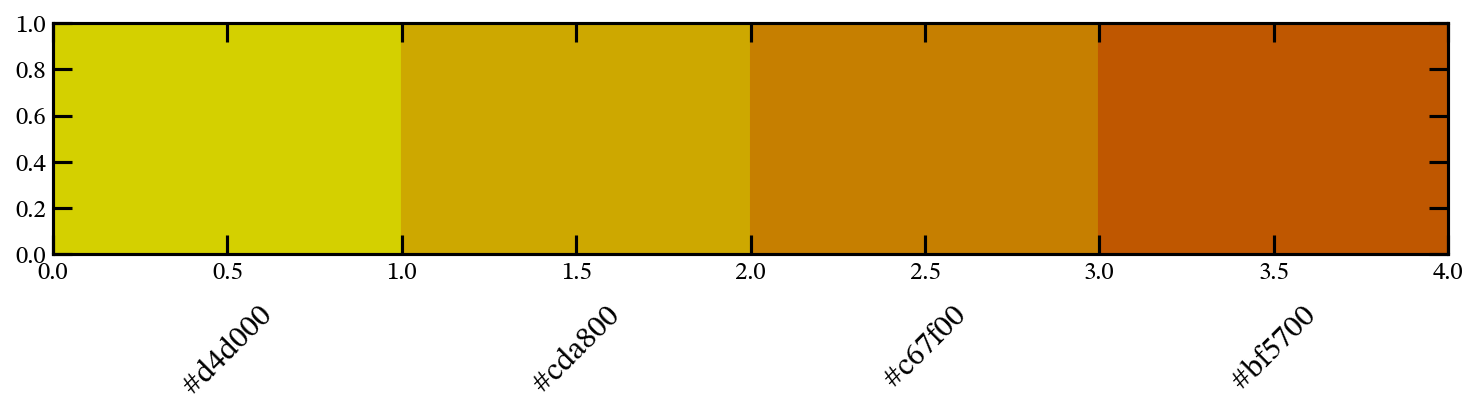

In [152]:
eplots.interpolate_colors([eplots.yellow, eplots.orange], 4)

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_34724/3459132455.py:110: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_34724/3459132455.py:110: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)


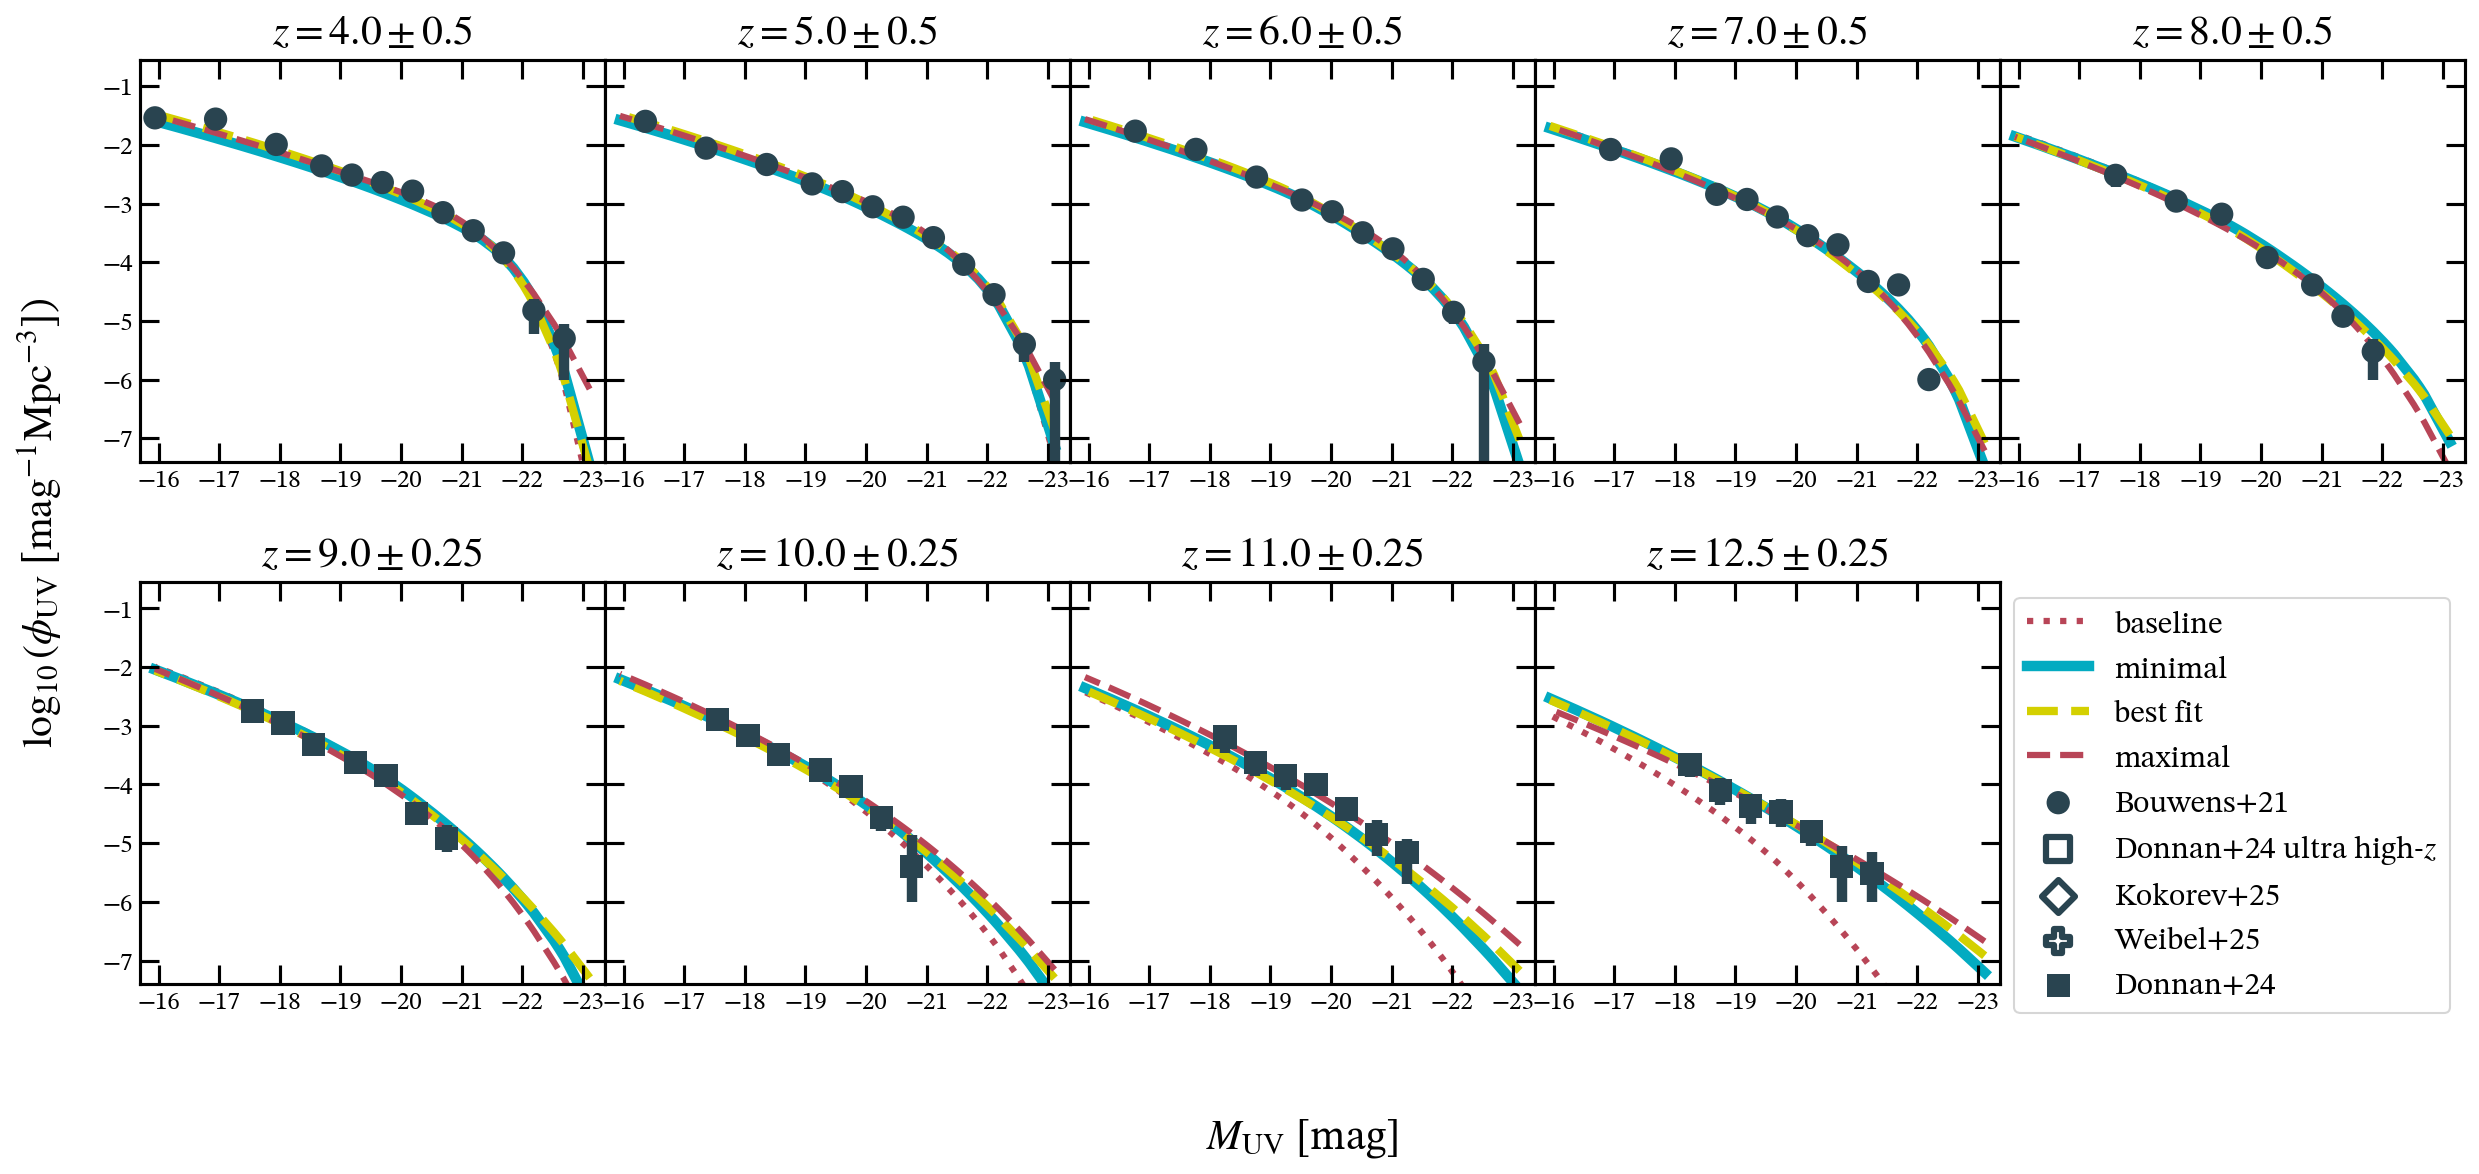

In [167]:
zs = [4, 5, 6, 7, 8, 9, 10, 11, 12.5]
z_errs = [0.5, 0.5, 0.5, 0.5,0.5, 0.25, 0.25, 0.25, 0.25]
evolving_UVLF = evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [baseline, minimal, best_fit, maximal],
                    comparison_labels = ['baseline', 'minimal', 'best fit', 'maximal'], 
                    ncols = 5, 
                fit_colors = [eplots.red, eplots.turquoise, eplots.yellow, eplots.red],  
                z_plot = zs, z_errs = z_errs, show_chi2 = False, max_sigs = None)

In [164]:
evolving_UVLF.savefig('/Users/eb35267/Desktop/figures/paper/UVLF.png', dpi = 300)

In [127]:
test = np.array([1, 2, 3])

In [128]:
test.clip(min = 2, max = None)

array([2, 2, 3])

# sigma(z)

In [173]:
def sigma(z, params, zpivot = 8):
    sig0 = params[:, -2].reshape(-1, 1)
    dsigdz = params[:,-1].reshape(-1, 1)
    min_sig = 0.3

    return np.clip(sig0 + dsigdz*(z-zpivot), a_min = min_sig, a_max = None)

In [174]:
Mhtab = np.arange(9, 13.5, 1.5)
zs = np.linspace(4, 13, 50)

cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.periwinkle, eplots.red], Mhtab)

In [175]:
distributions = np.percentile(sigma(zs, samples), q = [34, 50, 68], axis = 0)

In [176]:
def gelli(Mh):
    return (-0.34*np.log10(Mh)) + 4.5

## Attempting to quantify the mass dependence of sigma by tracing peak height over time

In [169]:
def get_Mh_ph(peak_height, my_UVLF, zs = None):
    if zs is None:
        zs = my_UVLF.zs

    HMF = my_UVLF.HMFintclass
    target_sig = my_UVLF.CosmoParams.delta_crit_ST/peak_height

    sig_tab = HMF.sigmaMhtab

    target_Mhs = np.zeros_like(zs)
    for i, z in enumerate(zs):
        idx = np.argmin(np.abs(sig_tab[:,np.argmin(np.abs(HMF.zHMFtab - z))] - target_sig))
        target_Mhs[i] = HMF.Mhtab[idx]

    return target_Mhs

In [187]:
trace_const_overdensity = get_Mh_ph(3, my_UVLF, None)

In [188]:
np.log10(trace_const_overdensity)

array([11.98507463, 11.58208955, 11.04477612, 10.50746269,  9.97014925,
        9.56716418,  9.02985075,  8.62686567,  7.95522388])

In [189]:
gelli_const_overdensity = gelli(trace_const_overdensity)

In [192]:
# # This is without dlogMc/dz: 
# sigma = [0.335, 0.38, 0.337, 0.322, 0.104, 0.129, 0.495, 1.079, 1.15]
# sigma_plus = [0.06, 0.07, 0.06, 0.09, 0.12, 0.12, 0.07, 0.07, 0.07, ]
# sigma_minus = [0.08, 0.195, 0.08, 0.08, 0, 0.01, 0.195, 0.11, 0.12, ]

# With dlogMc/dz:
sigma = [0.341, 0.317, 0.289, 0.387, 0.1, 0.454, 0.918, 1.397, 1.533]
sigma_plus = [0.05, 0.05, 0.07, 0.07, 0.22, 0.08, 0.07, 0.06, 0.06]
sigma_minus = [0.08, 0.07, 0.05, 0.11, 0, 0.2, 0.12, 0.1, 0.1]

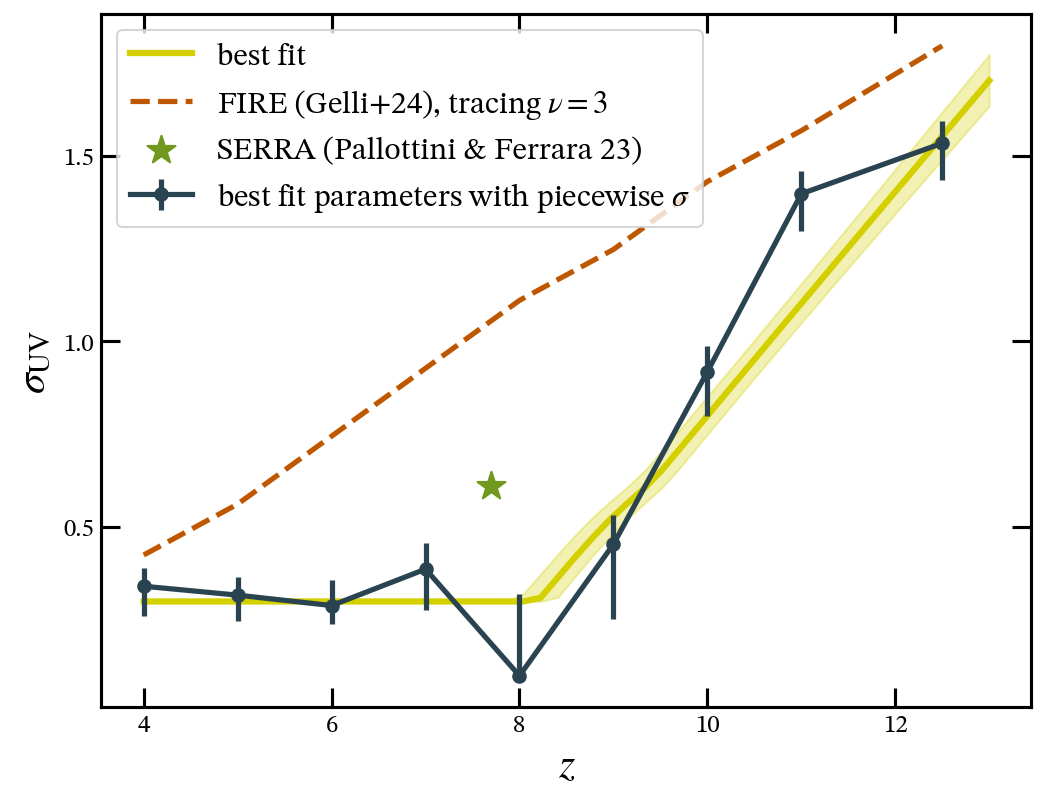

In [223]:
fig, ax = plt.subplots()
fig.set_size_inches(8, 6)

ax.plot(zs, distributions[1], color = eplots.yellow, ls = '-', label = 'best fit')
ax.fill_between(zs, distributions[0], distributions[2], color = eplots.yellow, alpha = 0.3)
ax.errorbar(my_UVLF.zs, sigma, color = eplots.navy, yerr = yerr, ecolor = eplots.navy, 
            label = r'best fit parameters with piecewise $\sigma$', markeredgecolor = eplots.navy, markersize = 6, fmt = 'o-', lw = 2.5)


ax.plot(my_UVLF.zs, gelli_const_overdensity, color = eplots.orange, ls = 'dashed', lw = 2.5, label = r'FIRE (Gelli+24), tracing $\nu = 3$' )

yerr = np.vstack((sigma_minus, sigma_plus))

ax.scatter(7.7, 0.61, color = eplots.green, marker = '*', s = 200, label = 'SERRA (Pallottini & Ferrara 23)')

ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$\sigma_{\rm{UV}}$')

ax.legend()

In [217]:
fig.savefig('/Users/eb35267/Desktop/figures/paper/sigma(z).png', dpi = 300)

# Delta chi squared

In [139]:
base_chisq = 105
chisq_1 = np.array([103, 101, 99, 98, 74, 96, 90, 105])
base_chisq_1 = 74
chisq_2 = np.array([58, 55, 53, 54, 74, 73, 60, 73.85])
labels = [r'$d\alpha/dz$', r'$d\beta/dz$', r'$d\log_{10} M_{c}/dz$', r'$d\log_{10}\epsilon_{\star, \rm{UV}}/dz$', r'$d\sigma_{\rm{UV}}/dz$', r'$d\sigma_{\rm{UV}}/d\log_{10}M_{\rm{h}}$', 
            r'$C_0, C_1$', r'$\min(\sigma_{\rm{UV}})$']

In [143]:
labels

['$d\\alpha/dz$',
 '$d\\beta/dz$',
 '$d\\log_{10} M_{c}/dz$',
 '$d\\log_{10}\\epsilon_{\\star, \\rm{UV}}/dz$',
 '$d\\sigma_{\\rm{UV}}/dz$',
 '$d\\sigma_{\\rm{UV}}/d\\log_{10}M_{\\rm{h}}$',
 '$C_0, C_1$',
 '$\\min(\\sigma_{\\rm{UV}})$']

In [144]:
labels[:4]

['$d\\alpha/dz$',
 '$d\\beta/dz$',
 '$d\\log_{10} M_{c}/dz$',
 '$d\\log_{10}\\epsilon_{\\star, \\rm{UV}}/dz$']

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_34724/1748687767.py:19: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta \chi^2$')


Text(0, 0.5, '$\\Delta \\chi^2$')

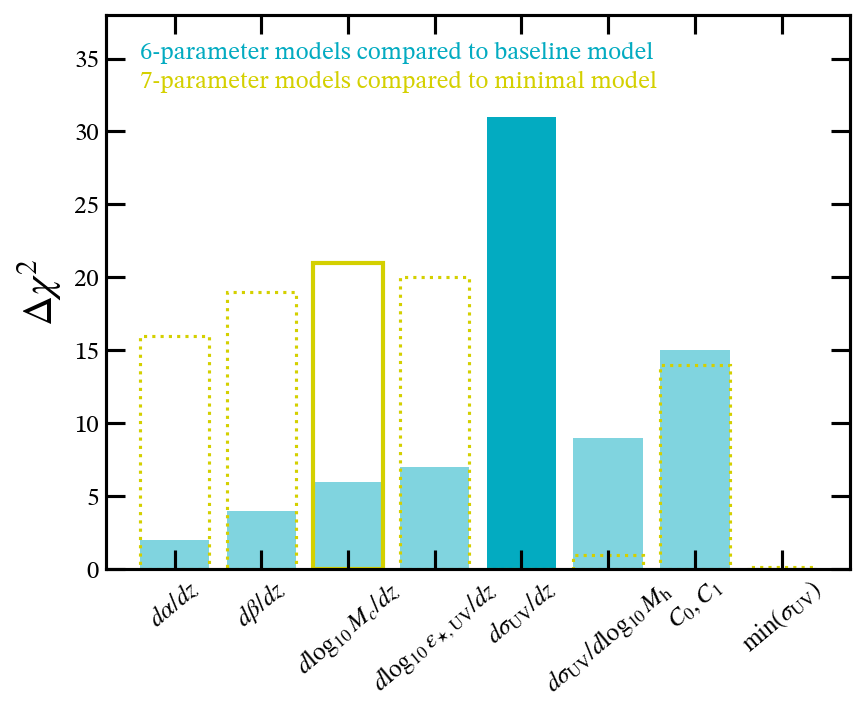

In [168]:
minimal_color = eplots.turquoise
bf_color = eplots.yellow

fig, ax = plt.subplots()
ax.bar(labels[:4], base_chisq-chisq_1[:4], color = minimal_color, alpha = 0.5)
ax.bar(labels[4], base_chisq-chisq_1[4], color = minimal_color)
ax.bar(labels[5:], base_chisq-chisq_1[5:], color = minimal_color, alpha = 0.5)

ax.bar(labels[:2], base_chisq_1 - chisq_2[:2], fill = False, edgecolor = bf_color, linewidth = 1.5, ls = 'dotted')
ax.bar(labels[2], base_chisq_1 - chisq_2[2], fill = False, edgecolor = bf_color, linewidth = 2, ls = 'solid')
ax.bar(labels[3:], base_chisq_1 - chisq_2[3:], fill = False, edgecolor = bf_color, linewidth = 1.5, ls = 'dotted')
plt.xticks(rotation=40, ha='center')

ax.set_ylim(None, 38)

ax.text(-0.4, 35, '6-parameter models compared to baseline model', fontsize = 12, color = minimal_color)
ax.text(-0.4, 33, '7-parameter models compared to minimal model', fontsize = 12, color = bf_color)

ax.set_ylabel('$\Delta \chi^2$')

In [166]:
fig.savefig('/Users/eb35267/Desktop/figures/paper/delta_chisq.png', dpi = 300)

In [99]:
N = len(np.concatenate([dat[2] for dat in my_UVLF.data]))

In [104]:
chinu_base = 105/(N-5)
print(chinu_base)

chinu_1 = 74/(N-6)
print(chinu_1)

chinu_2 = 53/(N-7)
print(chinu_2)

1.4189189189189189
1.0136986301369864
0.7361111111111112


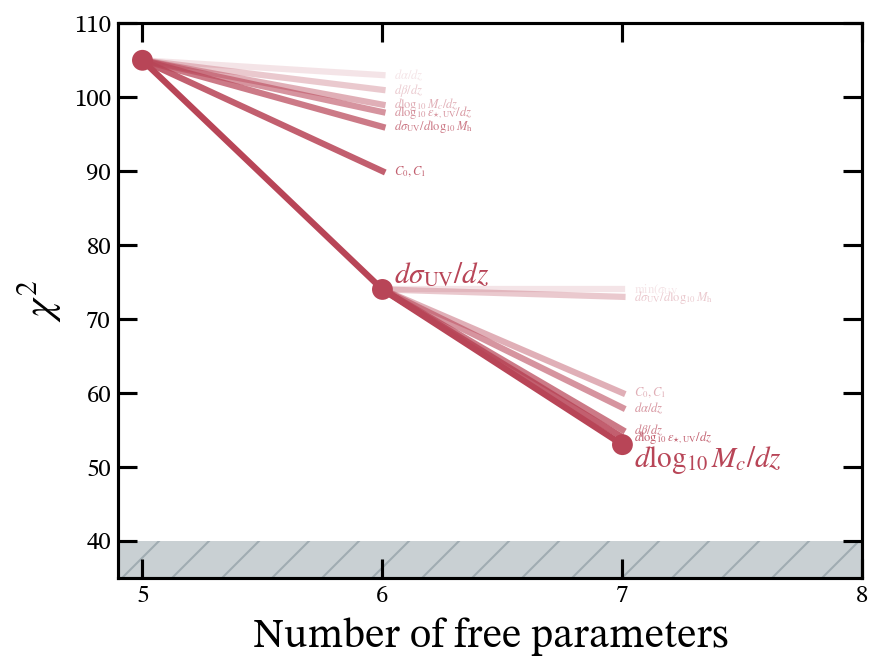

In [ ]:
# fig, ax = plt.subplots()

# ax.scatter(5, base_chisq, c = eplots.red, s = 100)
# for i, (chii, label) in enumerate(zip(chisq_1, labels_1)):
#     alpha = (i+1)/(len(chisq_1)+1)
#     ax.plot([5, 6], [base_chisq, chii], ls = 'solid', color = eplots.red, alpha = alpha)
#     ax.text(6.05, chii, label, color = eplots.red, alpha = alpha, va = 'center', fontsize = 6)

# ax.plot([5, 6], [base_chisq, best_1], ls = 'solid', color = eplots.red)
# ax.scatter(6, best_1, c = eplots.red, s = 100)
# ax.text(6.05, best_1+2, r'$d\sigma_{\rm{UV}}/dz$', fontsize = 14, va = 'center', color = eplots.red)

# for i, (chii, label) in enumerate(zip(chisq_2, labels_2)):
#     alpha = (i+1)/(len(chisq_2)+1)
#     ax.plot([6, 7], [best_1, chii], ls = 'solid', color = eplots.red, alpha = alpha)
#     ax.text(7.05, chii, label, color = eplots.red, alpha = alpha, va = 'center', fontsize = 6)

# ax.plot([6, 7], [best_1, best_2], ls = 'solid', color = eplots.red)
# ax.scatter(7, best_2, c = eplots.red, s = 100)
# ax.text(7.05, best_2-2, r'$d\log_{10} M_{c}/dz$', fontsize = 14, va = 'center', color = eplots.red)

# ax.set_xlim(4.9, 8)
# ax.set_ylim(35, 110)

# ax.fill_between([0, 10], [0], [40], color = eplots.navy, alpha = 0.25, edgecolor = None, hatch = '/')

# ax.set_ylabel(r'$\chi^2$')
# ax.set_xlabel('Number of free parameters')
# ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) 

In [225]:
fig.savefig('/Users/eb35267/Desktop/figures/paper/delta_chisq.png', dpi = 300)

# SFE plot

In [290]:
comparison_params = eMCMC.build_param_data({'dsigdz':{'fit':True}, 'dlogedz':{'fit':True}, 'dlogMcdz':{'fit':True}})
comparison_UVLF = eMCMC.UVLF(sorted_data, comparison_params)

In [289]:
add_deps_fit = [0.553, -0.865, 11.945, 0, -0.851, -0.04, 0.17, 0.3]
add_dMdz_fit = [0.534, -0.785, 12.259, 0.09, -0.724, 0, 0.227, 0.298]

In [357]:
def Mh(n, z):
    Mhs = my_UVLF.HMFintclass.Mhtab
    HMF = my_UVLF.HMFintclass.HMF_int(Mhs, z) * Mhs

    return np.log10(Mhs[np.argmin(np.abs(HMF - n))])

In [511]:
def sfe_shape_diff_z(my_UVLF, comparison_fits, fit_labels, zs = None, Mhtab = None):
    """
    Plot SFE vs. halo mass at different redshifts
    Inputs:
        my_UVLF [eMCMC UVLF object]: UVLF object used for its methods such as applying time evolution to parameter values & wrapping them in the
                                        right format for zeus21
        param_values [1darray]: values of parameters to calculate SFE
        zs [1darray]: redshifts to plot
        Mhtab [1darray]: log10(Mh) to plot over
        id_max [bool]: Whether or not to identify the maximum SFE at the highest and lowest redshift bin
    Returns:
        fig: A figure showing the SFE over the range of given halo masses & redshifts
    """

    if zs is None:
        zs = np.arange(4, 16, 2)

    if Mhtab is None: 
        Mhtab = np.linspace(9, 13, 200)

    fig = plt.figure(figsize=(6, 4.5))            
    ax_rect  = [0.10, 0.12, 0.78, 0.80]       # left, bottom, width, height (0-1)
    cax_rect = [0.895, 0.12, 0.04, 0.80]      # narrow right slot for cbar
    ax = fig.add_axes(ax_rect)

    if len(zs)>1:
        cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.yellow, eplots.turquoise], zs)

    linestyles = ['solid', 'dashed']

    ax.set_yscale('log')


    tickwidth = matplotlib.rcParams['xtick.major.width']
    ticklen = matplotlib.rcParams['xtick.major.size']
    
    for z in zs:
        for param_values, ls in zip(comparison_fits, linestyles):
            # Calculate parameters at this z
            params = my_UVLF.time_evolution(param_values, z)
            Astro_Parameters = my_UVLF.param_wrapper(params)

        
            # Calculate SFE
            SFEs = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
                Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mhtab)
            # Assign color
            if len(zs) > 1:
                frac = (z - min(zs)) / (max(zs) - min(zs))
                color = cmap(frac)
            else:
                color = eplots.yellow
            # Plot
            plt.plot(Mhtab, SFEs, color = color, ls = ls, zorder = 0)
        
        ax.plot(Mh(1e-5, z), 0, marker=2, transform=ax.get_xaxis_transform(), 
            color=color, markersize=3*ticklen/4, markeredgewidth = tickwidth, markeredgecolor = color)
        ax.plot(Mh(1e-5, z), 1, marker=3, transform=ax.get_xaxis_transform(), 
            color=color, markersize=3*ticklen/4, markeredgewidth = tickwidth, markeredgecolor = color)
        
    if len(zs)>1:
    # Color bar things:
        cax = fig.add_axes(cax_rect)
        cbar = fig.colorbar(sm, cax=cax, boundaries=boundaries, ticks=zs, aspect = 14)
        cbar.set_label(r'$z$')

    # Labels
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$f_{\star} = \dot M_{\star} / \dot M_{\rm{gas}}$')

    for fit_label, ls in zip(fit_labels, linestyles):
        ax.plot(10, 1e-1, label = fit_label, ls = ls, color = 'black')

    
    ax.legend(loc = (0.45, 0.1))
        
    return fig 


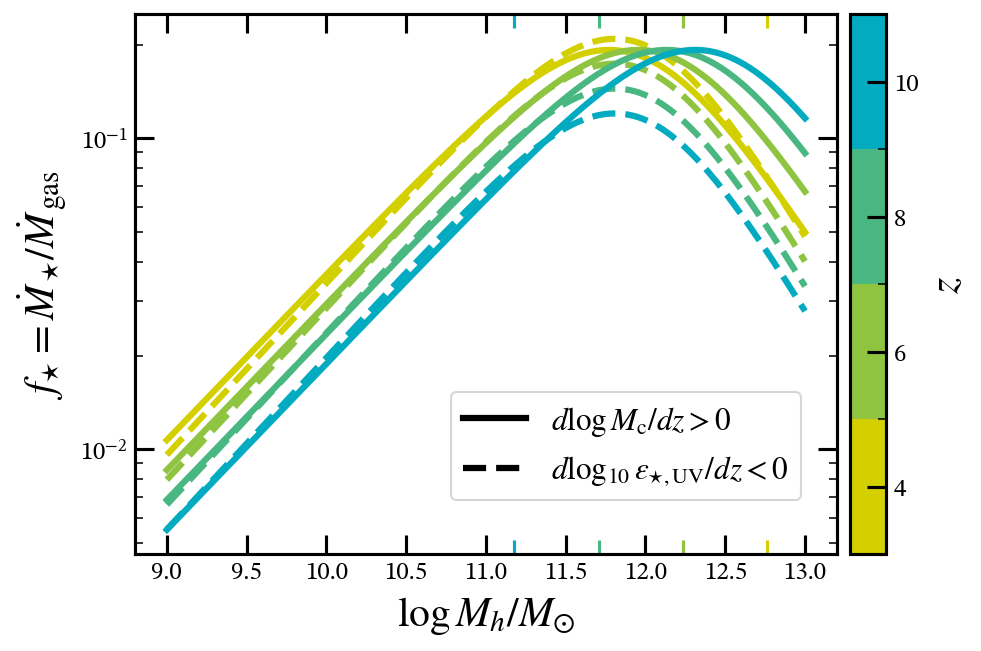

In [512]:
sfe_comparison = sfe_shape_diff_z(comparison_UVLF, [add_dMdz_fit, add_deps_fit], fit_labels = [r'$d\log M_{\rm{c}}/dz > 0$', r'$d\log_{10} \epsilon_{\star, \rm{UV}}/dz < 0$'], zs = np.arange(4, 12, 2))

In [514]:
sfe_comparison.savefig('/Users/eb35267/Desktop/figures/paper/sfe.png', dpi = 300)

# Bright end comparison

In [550]:
MUVcenters = np.arange(-24.5, -20.5, 0.14)
MUVwidths = np.full_like(MUVcenters, 0.5)
MUV_dat = (MUVcenters, MUVwidths)
zs = [6, 7, 8, 9]
z_err = [0.5, 0.5, 0.5, 0.25]

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_39526/1713937176.py:107: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_39526/1713937176.py:107: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)


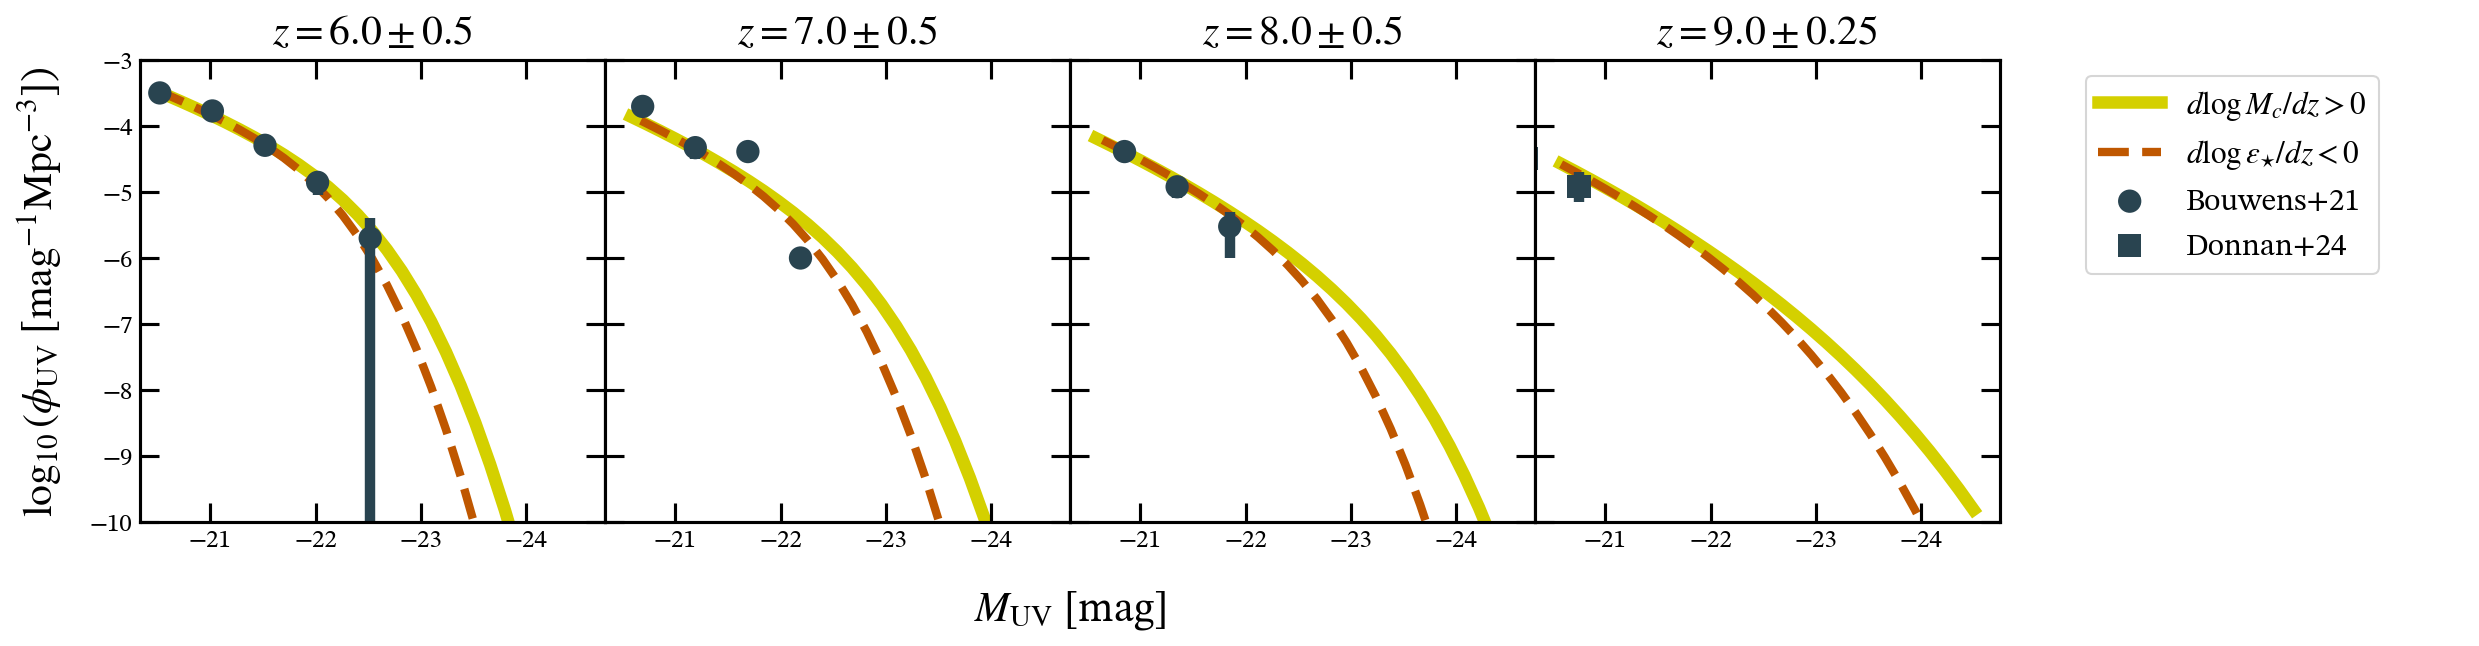

In [551]:
UVLF_plot = evolving_UVLF_fit(comparison_UVLF, plot_from_chain = False, comparison_fits = [add_dMdz_fit, add_deps_fit], 
                                     comparison_labels = [r'$d\log{M_c}/dz > 0$', r'$d\log{\epsilon_{\star}}/dz < 0$'], ncols = 5, 
                                     MUV_dat = MUV_dat, ylims = (-10, -3),
                                     z_plot = zs, z_errs=z_err, fit_colors = [eplots.yellow, eplots.orange], show_chi2=False)

In [552]:
UVLF_plot.savefig('/Users/eb35267/Desktop/figures/paper/bright_end_comparison.png', dpi = 300)

In [ ]:
fghksdfghdfg